In [11]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

class BlindBaselineWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        
        # The original pc-gym observation space has 9 elements. 
        # We delete index 4 (C) to shrink the boundaries down to 8 elements.
        # low = np.delete(self.env.observation_space.low, 4)   
        # high = np.delete(self.env.observation_space.high, 4) 
        # We delete index 3 (mu3) to shrink the boundaries down to 7 elements.
        low = np.delete(self.env.observation_space.low,[3,4])   
        high = np.delete(self.env.observation_space.high,[3,4]) 

        # Redefine the space so PPO allocates an 7-neuron input layer
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)

    def observation(self, obs):
        # Every time the environment returns an observation during reset() or step(),
        # we drop index 3 (mu3) before the PPO agent can see it.
        return np.delete(obs, [3,4])
    
    def plot_rollout(self, policy, reps=1, save_fig=False, filename='blind_baseline_rollout.png'):
        """
        Custom rollout evaluation loop that safely redirects step/reset engines
        to track policy behavior with the 7-input blind observation configuration.
        """
        # Save original target references
        orig_step = self.env.step
        orig_reset = self.env.reset

        try:
            # Monkeypatch the inner environment methods to point to our wrapper's logic
            self.env.step = self.step
            self.env.reset = self.reset

            # Grab process constants from the unwrapped environment
            N = self.env.unwrapped.N
            Nx = self.env.unwrapped.Nx
            Nu = self.env.unwrapped.env_params["a_space"]["low"].shape[0]

            # Arrays to aggregate trajectories over multiple reps
            all_states = np.zeros((Nx, N, reps))
            all_actions = np.zeros((Nu, N, reps))
            all_rewards = np.zeros((1, N, reps))

            for r in range(reps):
                # 1. Reset Phase
                obs, info = self.reset()
                
                states = np.zeros((Nx, N))
                actions = np.zeros((Nu, N))
                rewards = np.zeros(N)

                # Capture physical initial state directly from the plant
                states[:, 0] = self.env.unwrapped.state
                rewards[0] = info.get("r_init", 0)

                # 2. Simulation Step-by-Step Loop
                for t in range(N - 1):
                    # Policy receives the trimmed 7-input observation
                    action, _ = policy.predict(obs, deterministic=True)
                    next_obs, reward, terminated, truncated, info = self.step(action)

                    # Store real physical mapped actions safely
                    actions[:, t] = (
                        (action + 1)
                        * (self.env.unwrapped.env_params["a_space"]["high"] - self.env.unwrapped.env_params["a_space"]["low"]) / 2
                        + self.env.unwrapped.env_params["a_space"]["low"]
                    )

                    # Extract the true physical states directly from the unwrapped plant
                    states[:, t + 1] = self.env.unwrapped.state
                    rewards[t + 1] = reward
                    obs = next_obs

                    if terminated or truncated:
                        break

                # Handle final action at horizon boundary
                action, _ = policy.predict(obs, deterministic=True)
                actions[:, -1] = (
                    (action + 1)
                    * (self.env.unwrapped.env_params["a_space"]["high"] - self.env.unwrapped.env_params["a_space"]["low"]) / 2
                    + self.env.unwrapped.env_params["a_space"]["low"]
                )

                all_states[:, :, r] = states
                all_actions[:, :, r] = actions
                all_rewards[0, :, r] = rewards

            # 3. Plotting Setup (Averages out multiple runs if reps > 1)
            mean_states = np.mean(all_states, axis=2)
            mean_actions = np.mean(all_actions, axis=2)
            
            timesteps = np.arange(N)
            
            # Create a combined visualization plot layout (States + Actions)
            fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
            
            # Subplot 1: True Physical States over time
            for i in range(Nx):
                axes[0].plot(timesteps, mean_states[i, :], label=f'State $x_{i}$')
            axes[0].set_ylabel('Physical State Units')
            axes[0].set_title('Blind Baseline Process States Trajectory')
            axes[0].legend(loc='upper right', bbox_to_anchor=(1.15, 1))
            axes[0].grid(True, linestyle='--', alpha=0.5)

            # Subplot 2: Applied Control Actions over time
            for j in range(Nu):
                axes[1].plot(timesteps, mean_actions[j, :], label=f'Action $u_{j}$', linestyle='--')
            axes[1].set_xlabel('Timestep (t)')
            axes[1].set_ylabel('Action Space Units')
            axes[1].set_title('Control Action Profiles')
            axes[1].legend(loc='upper right', bbox_to_anchor=(1.15, 1))
            axes[1].grid(True, linestyle='--', alpha=0.5)

            plt.tight_layout()
            
            if save_fig:
                plt.savefig(filename, dpi=300, bbox_inches='tight')
                print(f"Rollout profile plot saved to {filename}")
            
            plt.show()

            # Format matching pc-gym's native payload expectations
            return {
                "Blind_Baseline": {
                    "x": all_states,
                    "u": all_actions,
                    "r": all_rewards
                }
            }

        finally:
            # Revert monkey-patch changes cleanly to prevent memory leak side-effects
            self.env.step = orig_step
            self.env.reset = orig_reset

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

class CustomPolicyEvaluator:
    """
    Standalone rollout evaluator for Stable-Baselines3 policies to ensure 
    identical evaluation logic and visualizations to pc-gym.
    """
    def __init__(self, env, model, n_steps=None):
        self.env = env
        self.model = model
        # Use environment's default horizon if n_steps is not provided
        self.n_steps = n_steps if n_steps is not None else getattr(env.unwrapped, 'N', 100)
        
    def run_rollout(self):
        state_dim = self.env.unwrapped.observation_space.shape[0]
        action_dim = self.env.unwrapped.action_space.shape[0]
        
        states = np.zeros((self.n_steps, state_dim))
        actions = np.zeros((self.n_steps, action_dim))
        rewards = np.zeros(self.n_steps)
        
        obs, info = self.env.reset()
        
        for t in range(self.n_steps):
            action, _states = self.model.predict(obs, deterministic=True)
            
            # Log the true physical state directly from the unnormalized unwrapped plant
            states[t, :] = self.env.unwrapped.state
            
            # Denormalize action to physical bounds
            act_high = self.env.unwrapped.action_space.high
            act_low = self.env.unwrapped.action_space.low
            physical_action = ((action + 1) * (act_high - act_low)) / 2.0 + act_low
            actions[t, :] = physical_action
            
            obs, reward, terminated, truncated, info = self.env.step(action)
            rewards[t] = reward
            
            if terminated or truncated:
                break
                
        return states, actions, rewards

    def plot_rollout(self, state_labels=None, action_labels=None, dist_reward=True):
        states, actions, rewards = self.run_rollout()
        time_steps = np.arange(self.n_steps)
        
        if state_labels is None:
            state_labels = [f"State {i}" for i in range(states.shape[1])]
        if action_labels is None:
            action_labels = [f"Action {i}" for i in range(actions.shape[1])]
            
        # If dist_reward is True, create 4 subplots (including the bar graph), otherwise 3
        n_plots = 4 if dist_reward else 3
        fig, axes = plt.subplots(n_plots, 1, figsize=(10, 3 * n_plots), sharex=False)
        
        # 1. Plot States
        for i in range(states.shape[1]):
            axes[0].plot(time_steps, states[:, i], label=state_labels[i])
        axes[0].set_title("True Environment Physical States (Ground Truth)")
        axes[0].set_ylabel("State Values")
        axes[0].legend(loc="upper right")
        axes[0].grid(True)
        
        # 2. Plot Actions
        for i in range(actions.shape[1]):
            axes[1].step(time_steps, actions[:, i], label=action_labels[i], where="post")
        axes[1].set_title("Physical Actions Executed")
        axes[1].set_ylabel("Action Values")
        axes[1].legend(loc="upper right")
        axes[1].grid(True)
        
        # 3. Plot Step-by-Step Reward
        axes[2].plot(time_steps, rewards, label="Reward per Step", color="r")
        axes[2].set_title("Step-by-Step Reward")
        axes[2].set_ylabel("Reward")
        axes[2].legend(loc="upper right")
        axes[2].grid(True)
        
        # 4. Reward Distribution Bar Graph (Histogram)
        if dist_reward:
            # Generate a continuous histogram distribution bar graph of the rewards
            axes[3].hist(rewards, bins=15, color='purple', alpha=0.7, edgecolor='black', label="Reward Frequency")
            axes[3].set_title("Reward Distribution (Frequency)")
            axes[3].set_xlabel("Reward Value Bounds")
            axes[3].set_ylabel("Frequency (Counts)")
            axes[3].legend(loc="upper right")
            axes[3].grid(True)
        else:
            axes[2].set_xlabel("Timestep")
            
        plt.tight_layout()
        plt.show()

In [14]:
import numpy as np
from pcgym import make_env
from stable_baselines3 import PPO

# =====================================================================
# 2. STANDARD FULL 9-DIMENSIONAL ENVIRONMENT CONFIGURATION
# =====================================================================
T = 30.0       
nsteps = 30    

SP = {
    'CV': [1.00 for _ in range(nsteps)],
    'Ln': [15.00 for _ in range(nsteps)]
}

action_space = {
    'low': np.array([-1.0]),   
    'high': np.array([1.0])    
}

# Keep all 9 elements here so pc-gym doesn't throw a JAX error
observation_space = {
    'low' : np.array([0.0, 0.0, 0.0, 0.0, 0.00, 0.00, 0.00, 0.00, 0.00]),
    'high' : np.array([1.0e20, 1.0e20, 1.0e20, 1.0e20, 0.50, 2.00, 20.00, 2.00, 20.00])  
}

env_params = {
    'N': nsteps, 
    'tsim': T, 
    'SP': SP, 
    'o_space': observation_space, 
    'a_space': action_space,
    
    # Fully populated 9-element initial state vector [mu0, mu1, mu2, mu3, C, CV, Ln, CV_SP, Ln_SP]
    'x0': np.array([1.50e3, 2.30e4, 2.50e8, 0.0, 0.16, 1.00, 15.00, 1.00, 15.00]),
    
    'r_scale': {
        'CV': 1e1,
        'Ln': 1e0
    },
    
    'model': 'crystallization', 
    'normalise_a': True, 
    'normalise_o': True, 
    'noise': True, 
    'integration_method': 'jax', 
    'noise_percentage': 0.01, 
}

# =====================================================================
# 3. INITIALIZE AND TRAIN THE BLIND BASELINE
# =====================================================================
# Create the true physical environment (9 dimensions)
base_env = make_env(env_params)

# Wrap it to make it blind (Converts to 7 dimensions for the agent)
blind_env = BlindBaselineWrapper(base_env)

# print("Wrapped /Obs Space Shape passed to PPO:", blind_env.observation_space.shape) # Output: (7,)

# Train your policy on the blind features
PPO_blind_policy = PPO('MlpPolicy', blind_env, verbose=1)
PPO_blind_policy.learn(total_timesteps=100000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 29        |
|    ep_rew_mean     | -1.08e+05 |
| time/              |           |
|    fps             | 85        |
|    iterations      | 1         |
|    time_elapsed    | 23        |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 29           |
|    ep_rew_mean          | -1.08e+05    |
| time/                   |              |
|    fps                  | 83           |
|    iterations           | 2            |
|    time_elapsed         | 48           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 6.094348e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2         

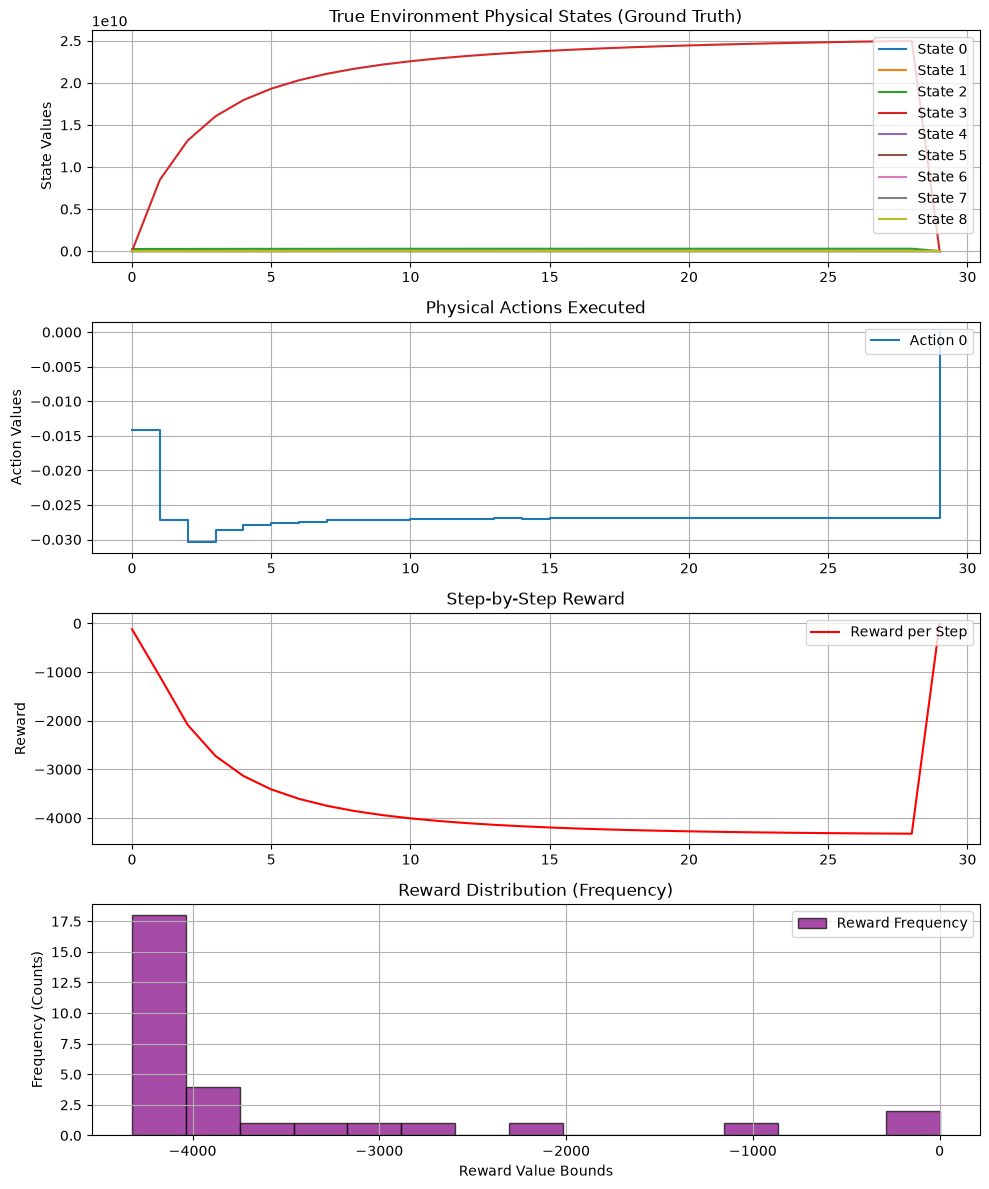

In [15]:
# 3. Initialize the standalone evaluator
evaluator = CustomPolicyEvaluator(env=blind_env, model=PPO_blind_policy)

evaluator.plot_rollout(dist_reward=True)

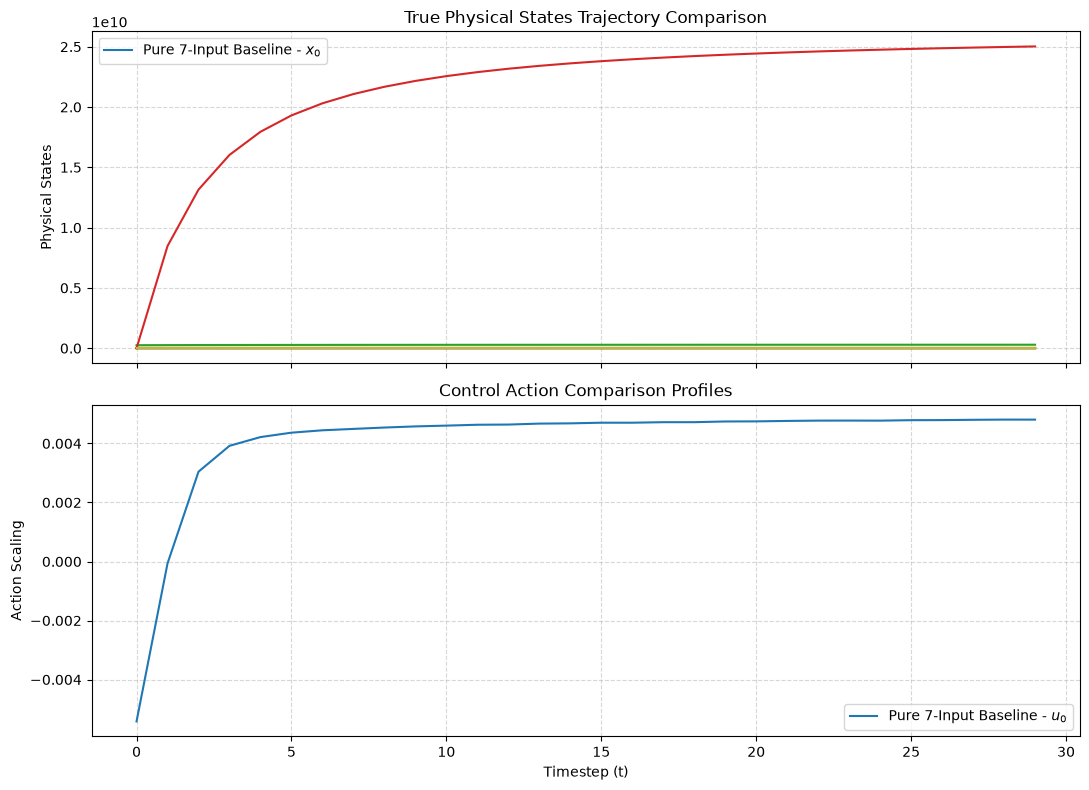

In [8]:
# Create evaluators for your different wrapped setups
evaluator_blind = CustomPolicyEvaluator(blind_env)

# Collect rollout data arrays
blind_data = evaluator_blind.run_rollout(PPO_blind_policy, reps=5)
# oracle_data = evaluator_blind.run_rollout(oracle_ppo_model, reps=5) # if comparing to fully-observable

# Plot the comparative datasets together on the same canvas
evaluator_blind.plot_comparison({
    "Pure 7-Input Baseline": blind_data,
})

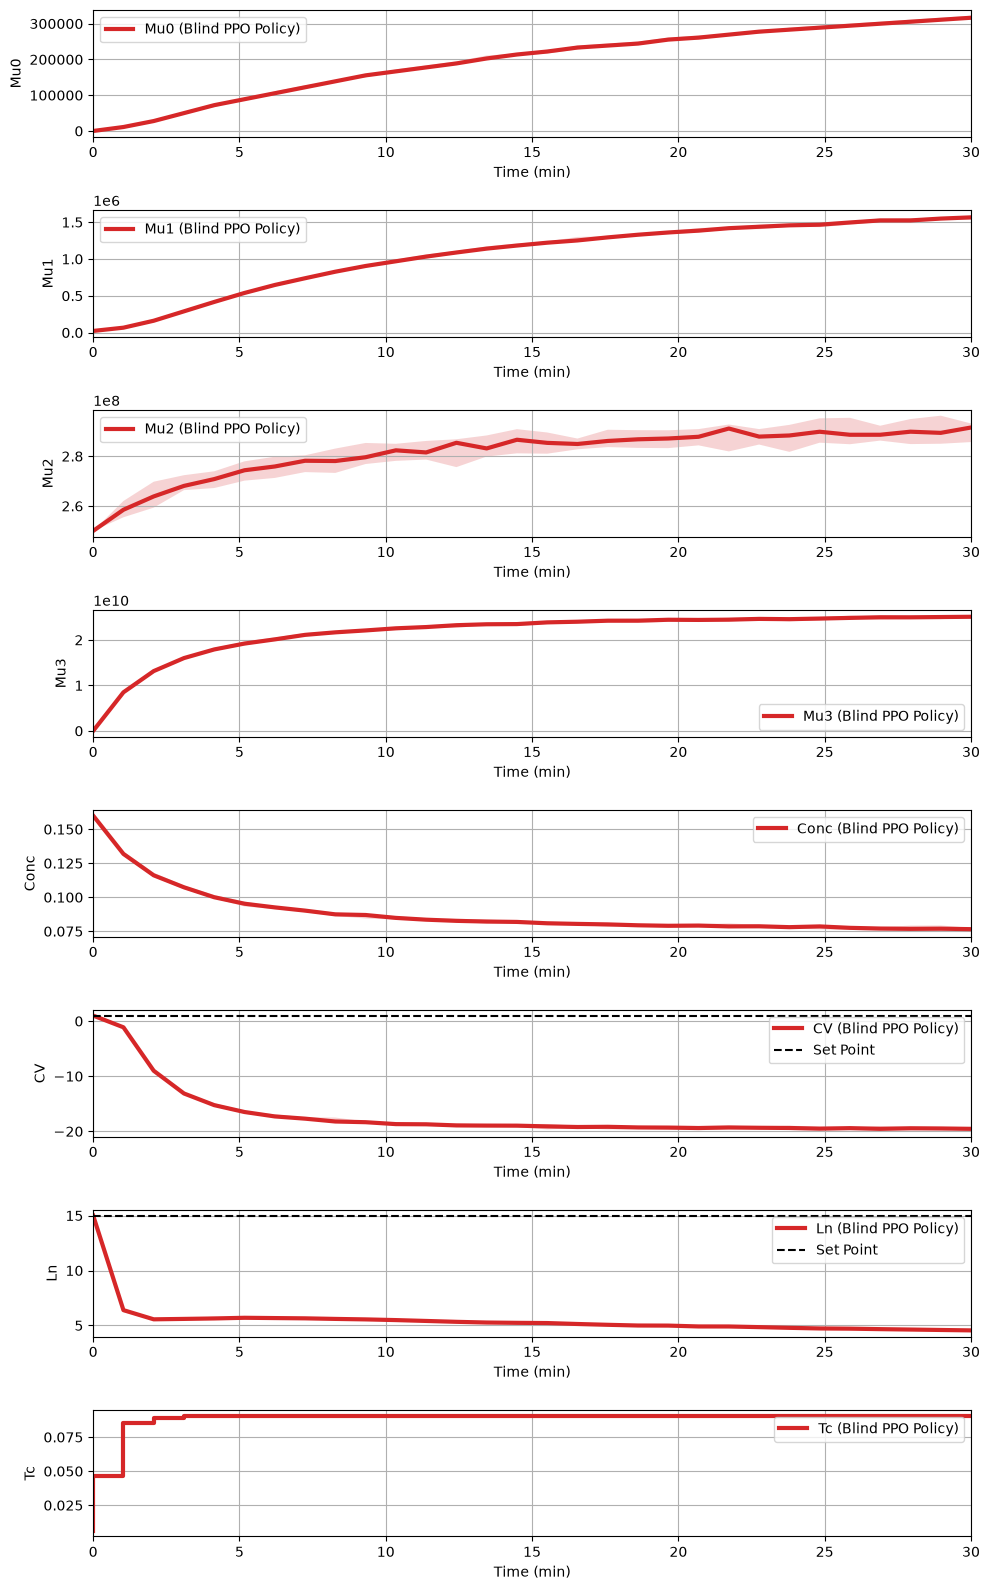

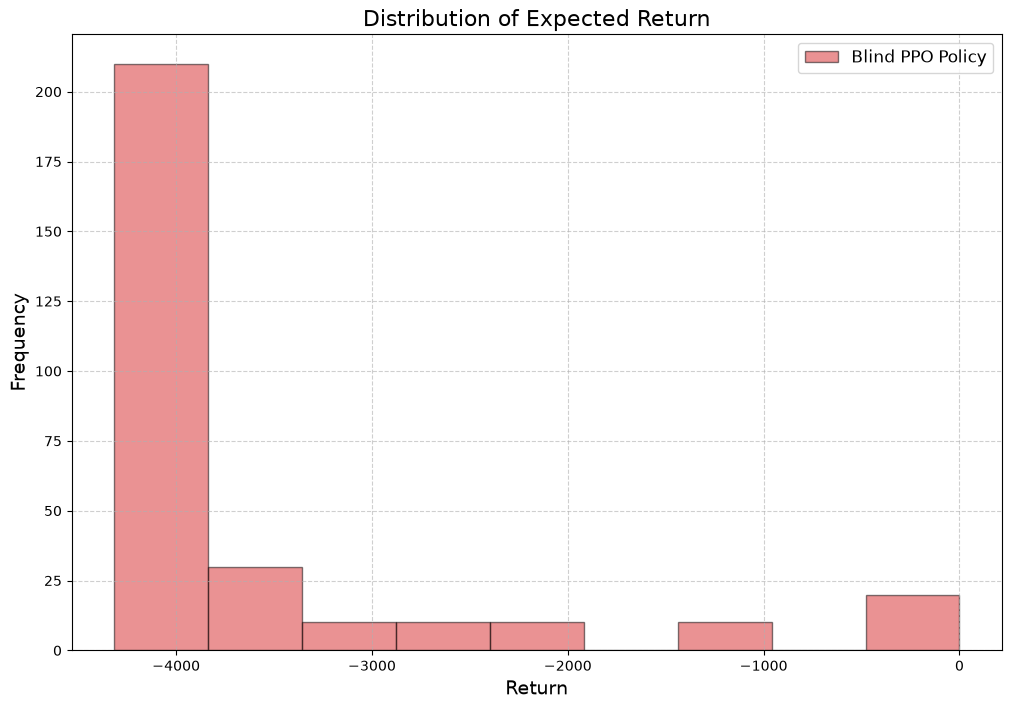

Your blind baseline final score is: -3598.71 (larger the better).


In [4]:
# =====================================================================
# DUMMY POLICY BRIDGE FOR EVALUATION
# =====================================================================
class BlindPolicyEvaluator:
    def __init__(self, trained_ppo_policy):
        self.policy = trained_ppo_policy

    def predict(self, obs, state=None, episode_start=None, deterministic=True):
        # 1. Slice out mu3 (index 3) from the 9-dimensional evaluation observation
        if len(obs.shape) > 1:
            # Handle vectorized environments / batches
            blind_obs = np.delete(obs, 3, axis=1)
        else:
            blind_obs = np.delete(obs, 3)
            
        # 2. Pass the clean 8-dimensional observation to your trained PPO policy
        return self.policy.predict(blind_obs, state, episode_start, deterministic)

# =====================================================================
# RUN THE EVALUATION
# =====================================================================
# Instantiate the evaluation bridge
evaluation_ready_policy = BlindPolicyEvaluator(PPO_blind_policy)

# Pass the wrapped policy to the BASE environment's plot_rollout tool
evaluator, data = base_env.plot_rollout(
    {'Blind PPO Policy': evaluation_ready_policy}, 
    reps=10, 
    oracle=False, 
    dist_reward=True
)

# Extract and print the final average score
res = data['Blind PPO Policy']['r'].mean()
print(f"Your blind baseline final score is: {res:.2f} (larger the better).")